In [1]:
# Reliance Industries Stock Forecasting
### Exploratory Data Analysis & Time Series Preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

In [3]:
#Explanation:These libraries provide tools for data manipulation, visualization, and time-series analysis.
#Why: They enable preprocessing, plotting, stationarity testing, and decomposition required for forecasting.

In [4]:
df = pd.read_csv("C:/Users/chand/Downloads/RELIANCE.NS.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-03,33.917892,35.945827,33.917892,35.945827,26.684866,31204789.0
1,2000-01-04,36.902668,38.823490,35.888702,38.823490,28.821142,66436055.0
2,2000-01-05,36.652744,41.115627,36.652744,40.344440,29.950235,187894923.0
3,2000-01-06,41.272720,42.943623,41.272720,42.036766,31.206556,109810562.0
4,2000-01-07,42.129593,45.399994,41.843967,44.921570,33.348133,139140630.0
...,...,...,...,...,...,...,...
6074,2024-04-23,2958.000000,2987.000000,2911.100098,2918.649902,2918.649902,7302777.0
6075,2024-04-24,2927.000000,2937.100098,2899.000000,2900.350098,2900.350098,5231388.0
6076,2024-04-25,2885.000000,2935.949951,2883.000000,2919.949951,2919.949951,7971963.0
6077,2024-04-26,2927.899902,2930.000000,2900.000000,2905.100098,2905.100098,4706924.0


In [5]:
#Explanation: Loads the stock dataset into a DataFrame for structured analysis.
#We use this to begin all preprocessing and modeling operations.

In [6]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-03,33.917892,35.945827,33.917892,35.945827,26.684866,31204789.0
1,2000-01-04,36.902668,38.823490,35.888702,38.823490,28.821142,66436055.0
2,2000-01-05,36.652744,41.115627,36.652744,40.344440,29.950235,187894923.0
3,2000-01-06,41.272720,42.943623,41.272720,42.036766,31.206556,109810562.0
4,2000-01-07,42.129593,45.399994,41.843967,44.921570,33.348133,139140630.0


In [7]:
print("Dataset Shape (Rows, Columns):", df.shape)

Dataset Shape (Rows, Columns): (6079, 7)


In [8]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6079 entries, 0 to 6078
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6079 non-null   object 
 1   Open       6069 non-null   float64
 2   High       6069 non-null   float64
 3   Low        6069 non-null   float64
 4   Close      6069 non-null   float64
 5   Adj Close  6069 non-null   float64
 6   Volume     6069 non-null   float64
dtypes: float64(6), object(1)
memory usage: 332.6+ KB


In [10]:
df.isnull().sum()

Date          0
Open         10
High         10
Low          10
Close        10
Adj Close    10
Volume       10
dtype: int64

In [11]:
# Fill missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Verify again
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [12]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Remove duplicates if any
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [13]:
df = df.dropna()
df.shape

(6079, 7)

In [14]:
#EDA

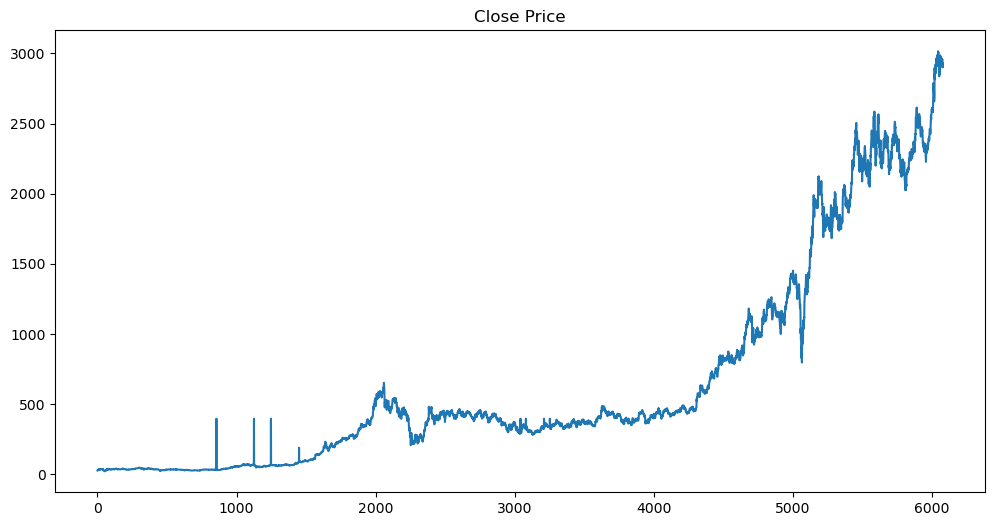

In [15]:
#1.)Trend & Bheavior analysis
plt.figure(figsize=(12,6))
plt.plot(df['Adj Close'])
plt.title("Close Price")
plt.show()

In [16]:
#Explanation:Visualizes historical price movement.
#Why: Identifies long-term growth and structural breaks.

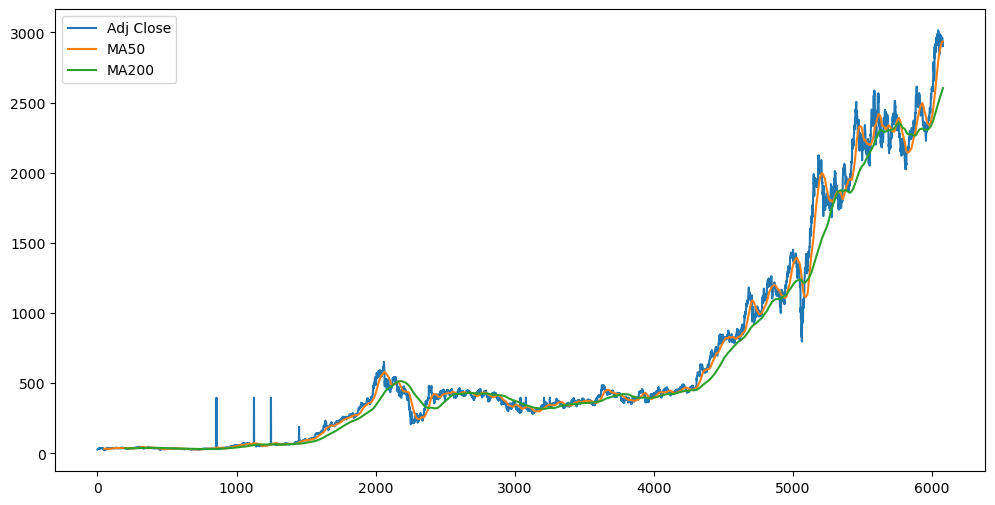

In [17]:
#Moving Averages
df['MA50'] = df['Adj Close'].rolling(50).mean()
df['MA200'] = df['Adj Close'].rolling(200).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Adj Close'], label='Adj Close')
plt.plot(df['MA50'], label='MA50')
plt.plot(df['MA200'], label='MA200')
plt.legend()
plt.show()

In [18]:
#Explanation:Computes short-term and long-term trend indicators.
#Why: Used to detect trend direction and crossovers.

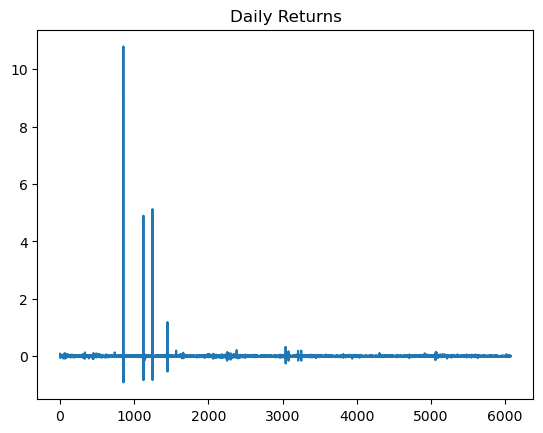

In [19]:
#Daily Returns
df['Returns'] = df['Adj Close'].pct_change()
plt.plot(df['Returns'])
plt.title("Daily Returns")
plt.show()

In [20]:
#Explanation:Calculates percentage price change between consecutive days.
#Why: Returns capture volatility better than raw prices.

In [21]:
df['Returns'] = df['Adj Close'].pct_change()
df['Volatility_30'] = df['Returns'].rolling(30).std()

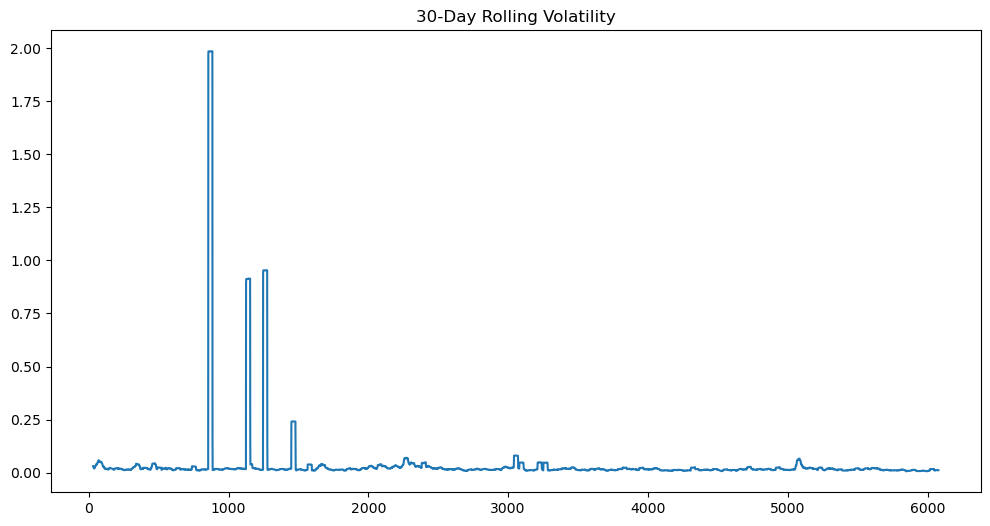

In [22]:
#Rolling Volatility
df['Volatility_30'] = df['Returns'].rolling(window=30).std()
plt.figure(figsize=(12,6))
plt.plot(df['Volatility_30'])
plt.title("30-Day Rolling Volatility")
plt.show()

In [23]:
#Explanation:Calculates 30-day rolling standard deviation of returns.
#Why: Measures volatility clustering in financial markets.

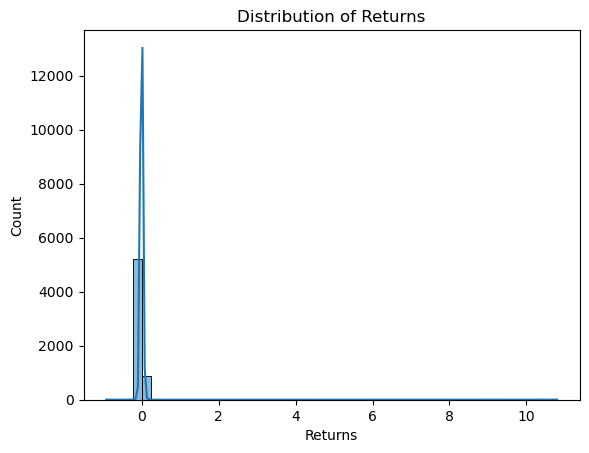

In [24]:
#Distribution of Returns
sns.histplot(df['Returns'].dropna(), bins=50, kde=True)
plt.title("Distribution of Returns")
plt.show()

In [25]:
#Explanation:Plots return distribution.
#Why: Helps assess skewness and extreme values.

In [26]:
#==============================
#Time Series Structure Analysis
#===============================

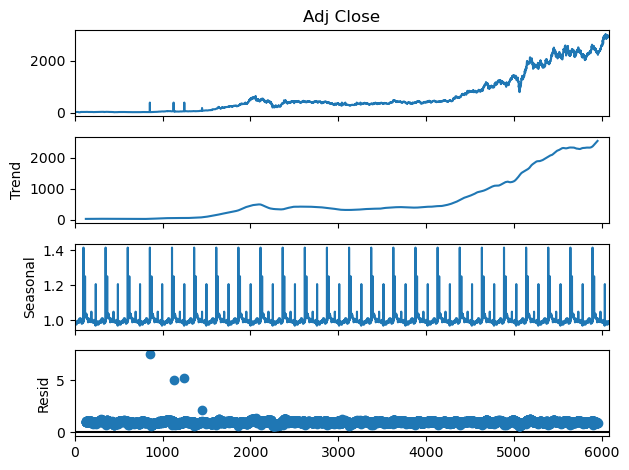

In [27]:
#Decomposition
decomposition = seasonal_decompose(df['Adj Close'], model='multiplicative', period=252)
decomposition.plot()
plt.show()

In [28]:
#Explanation:Breaks series into trend, seasonal, and residual components.
#Why: Identifies underlying time-series structure.

In [29]:
#ADF Test (Original Series)

result = adfuller(df['Adj Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 1.7196224301028196
p-value: 0.998175536916939


In [30]:
#Explanation:Tests whether the series is stationary and our value is~0.99 it is Non-Stationary .
#Why: Stationarity is required for ARIMA modeling.

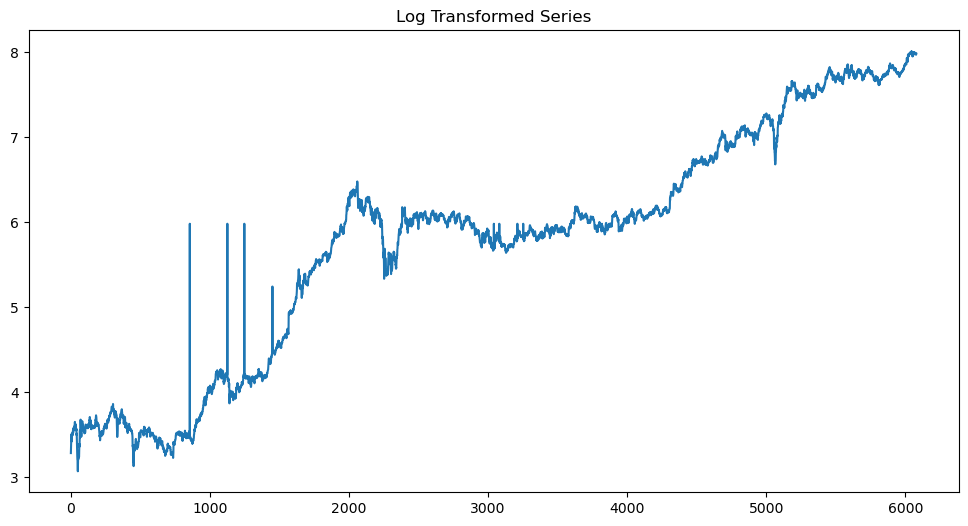

In [31]:
#Log Transformation
df['Log_Close'] = np.log(df['Adj Close'])
plt.figure(figsize=(12,6))
plt.plot(df['Log_Close'])
plt.title("Log Transformed Series")
plt.show()

In [32]:
#Explanation: Applies logarithmic transformation to stabilize variance in the price series.
#Why: Log transformation reduces exponential growth effects and helps in achieving stationarity.
#For Log_class
#Explanation: Plots the log-transformed series.
#Why: To visually inspect trend smoothness and variance stabilization.

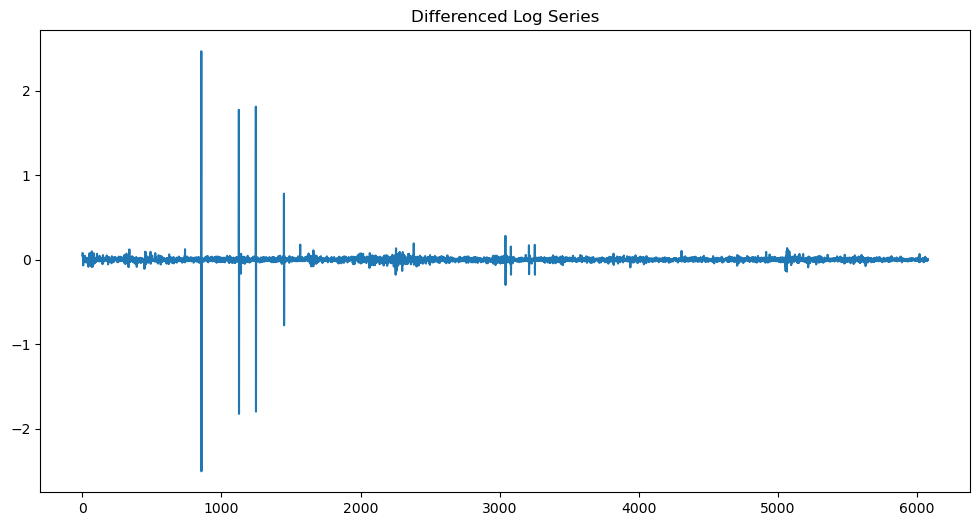

In [33]:
#Differencing
df['Diff_Log_Close'] = df['Log_Close'].diff()
plt.figure(figsize=(12,6))
plt.plot(df['Diff_Log_Close'])
plt.title("Differenced Log Series")
plt.show()

In [34]:
#Explanation: Computes first-order difference of log series.
#Why: Differencing removes trend and helps convert non-stationary data into stationary form.
#Diff Log_class
#Explanation: Plots differenced log series.
#Why: To visually confirm trend removal and stationarity behavior.

In [35]:

#ADF Test After Differencing
result_diff = adfuller(df['Diff_Log_Close'].dropna())
print("p-value after differencing:", result_diff[1])

p-value after differencing: 0.0


In [36]:
#Explanation: Performs Augmented Dickey-Fuller test on transformed series.
#Why: To statistically verify stationarity.

In [37]:
## Summary

#- The stock shows long-term upward trend with volatility clustering.
#- The original series was non-stationary.
#- After log transformation and differencing, stationarity was achieved.
#- The dataset is ready for feature engineering and forecasting.

In [38]:
#========================
#Data Visualisation
#========================

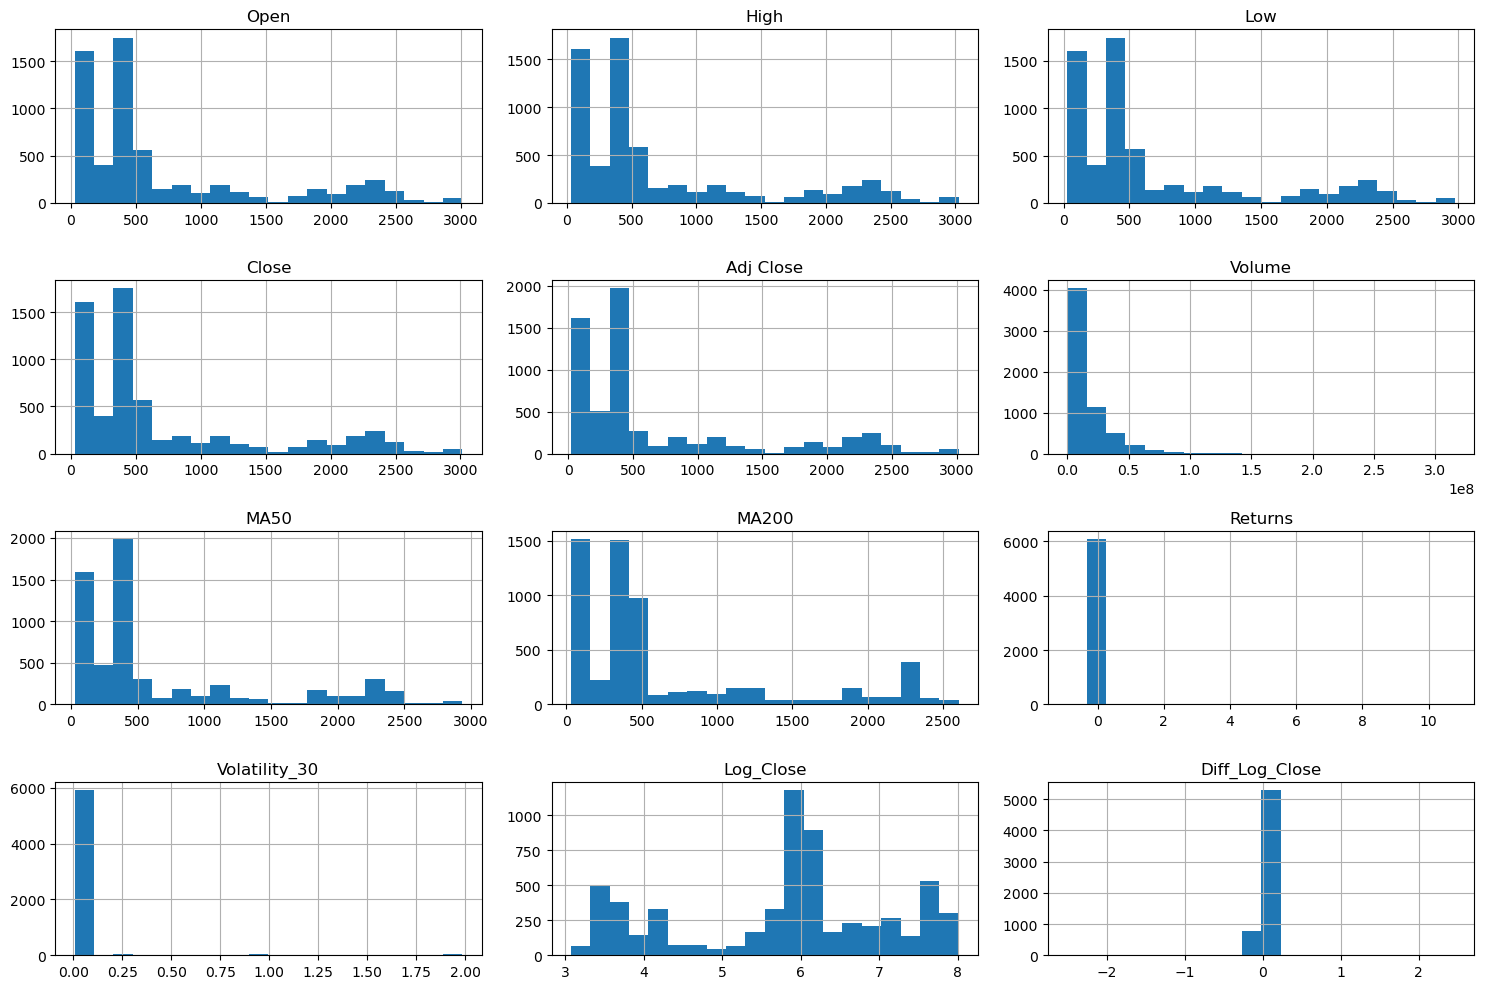

In [39]:
# histogram
df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

In [40]:
#Explanation: Generates distribution plots for all numerical variables.
#Why: To analyze data spread, skewness, and detect extreme values.

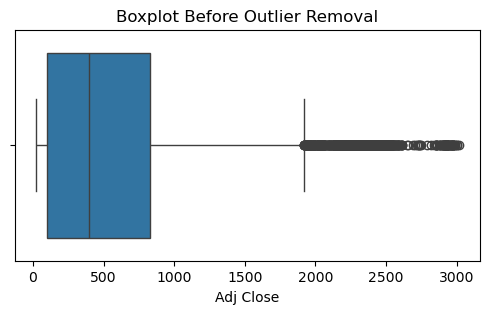

In [41]:
#Boxplot BEFORE Removing Outliers
plt.figure(figsize=(6,3))
sns.boxplot(x=df['Adj Close'])
plt.title("Boxplot Before Outlier Removal")
plt.show()

In [42]:
#Explanation: Visualizes distribution and potential outliers of closing price.
#Why: Boxplots help detect extreme values using IQR method.

In [43]:
# IQR Outlier Detection (For Visualization Only)
Q1 = df['Adj Close'].quantile(0.25)
Q3 = df['Adj Close'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[
    (df['Adj Close'] >= lower_bound) & (df['Adj Close'] <= upper_bound)]

In [44]:
#Explanation: Computes interquartile range.
#Why: IQR helps define statistical boundaries for detecting outliers.

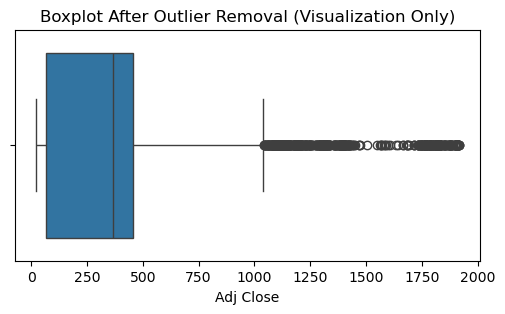

In [45]:
#Boxplot AFTER Removing Outliers
plt.figure(figsize=(6,3))
sns.boxplot(x=df_clean['Adj Close'])
plt.title("Boxplot After Outlier Removal (Visualization Only)")
plt.show()

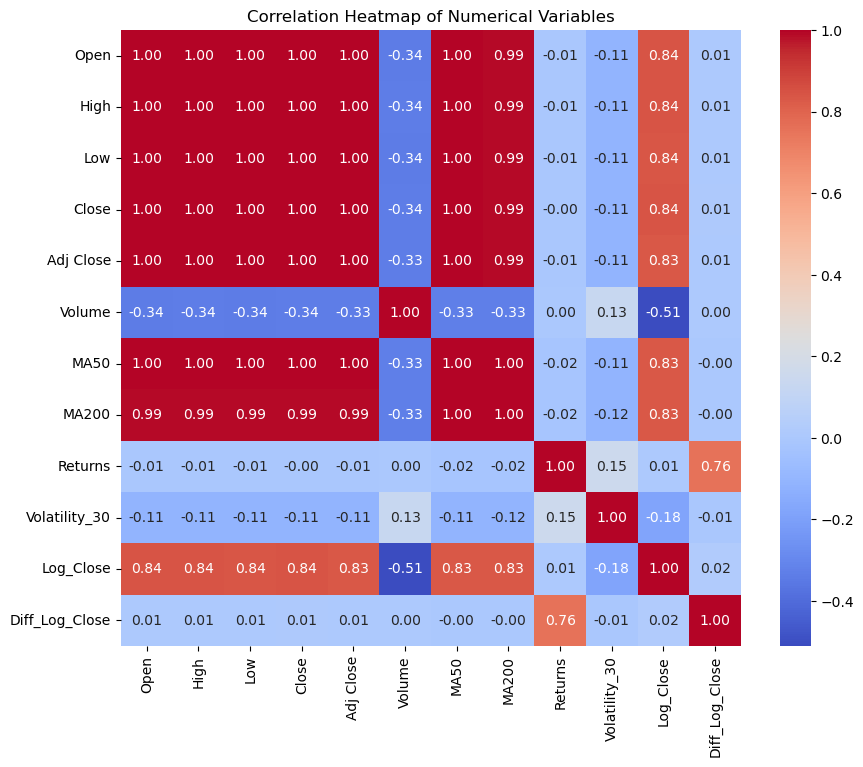

In [46]:
#CORRELATION HEATMAP CODE
num_df = df.select_dtypes(include=['int64', 'float64'])

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [47]:
#Explanation: Selects numerical features only.
#Why: Correlation analysis requires numeric variables.

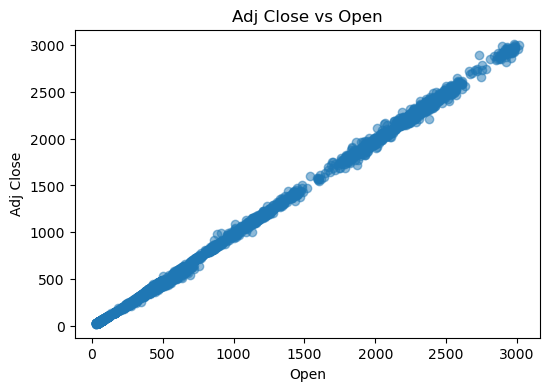

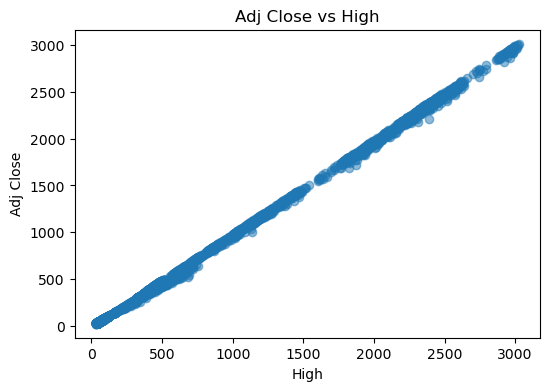

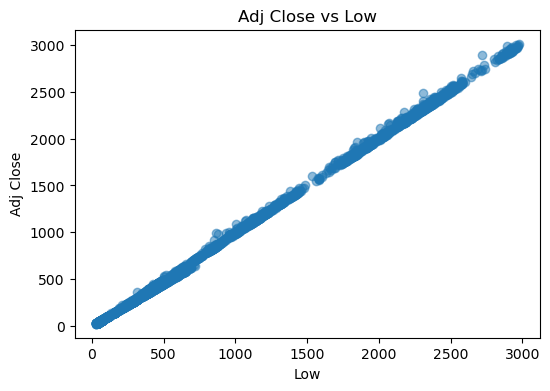

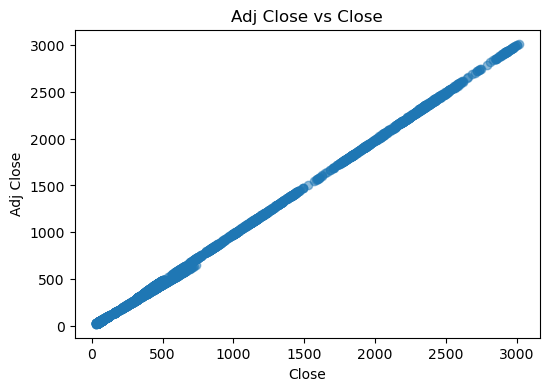

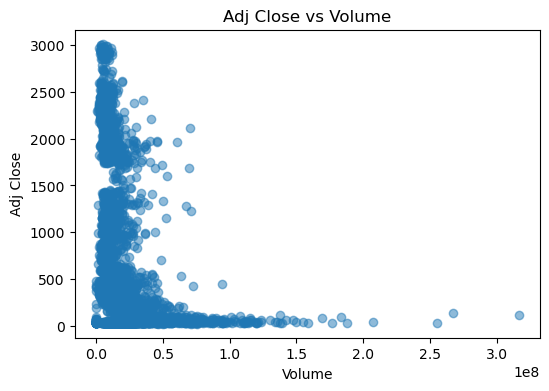

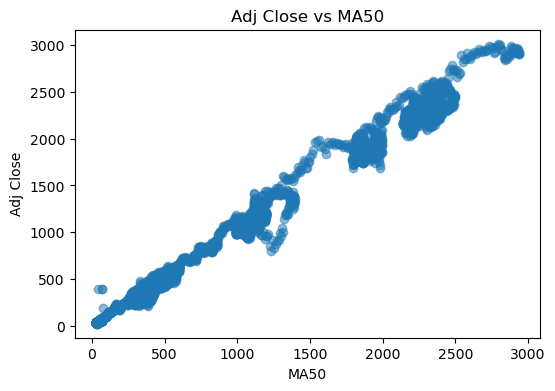

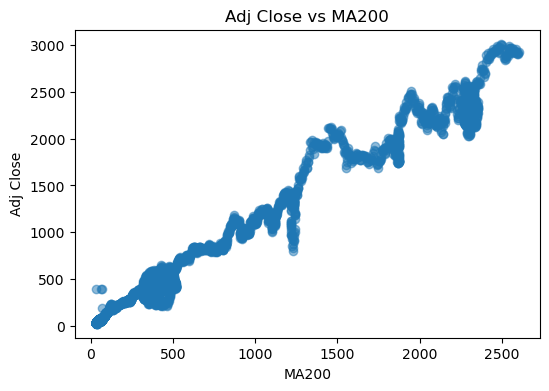

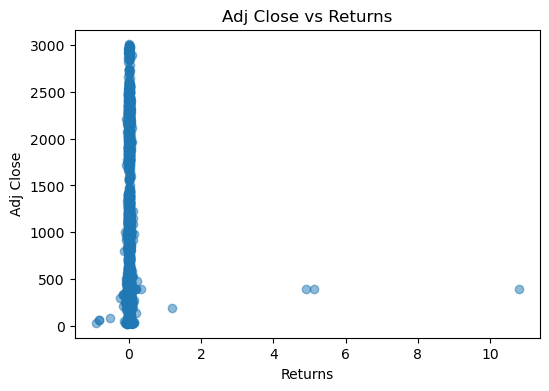

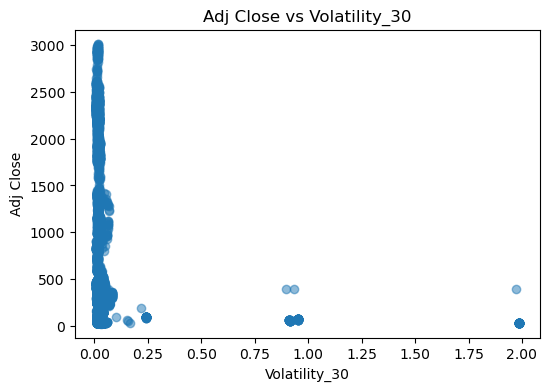

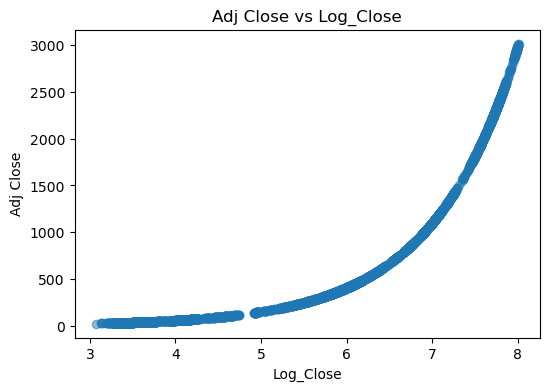

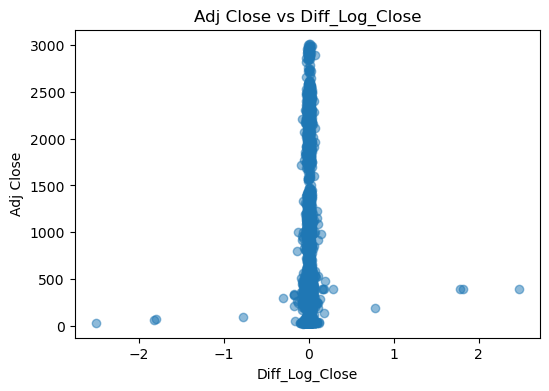

In [48]:
#scatter plot
import matplotlib.pyplot as plt

target = 'Adj Close'

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Scatter plot for each feature vs target
for col in num_cols:
    if col != target:
        plt.figure(figsize=(6,4))
        plt.scatter(df[col], df[target], alpha=0.5)
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f"{target} vs {col}")
        plt.show()

In [49]:
#Explanation: Plots relationship between feature and target variable.
#Why: To visually examine linear or nonlinear associations.

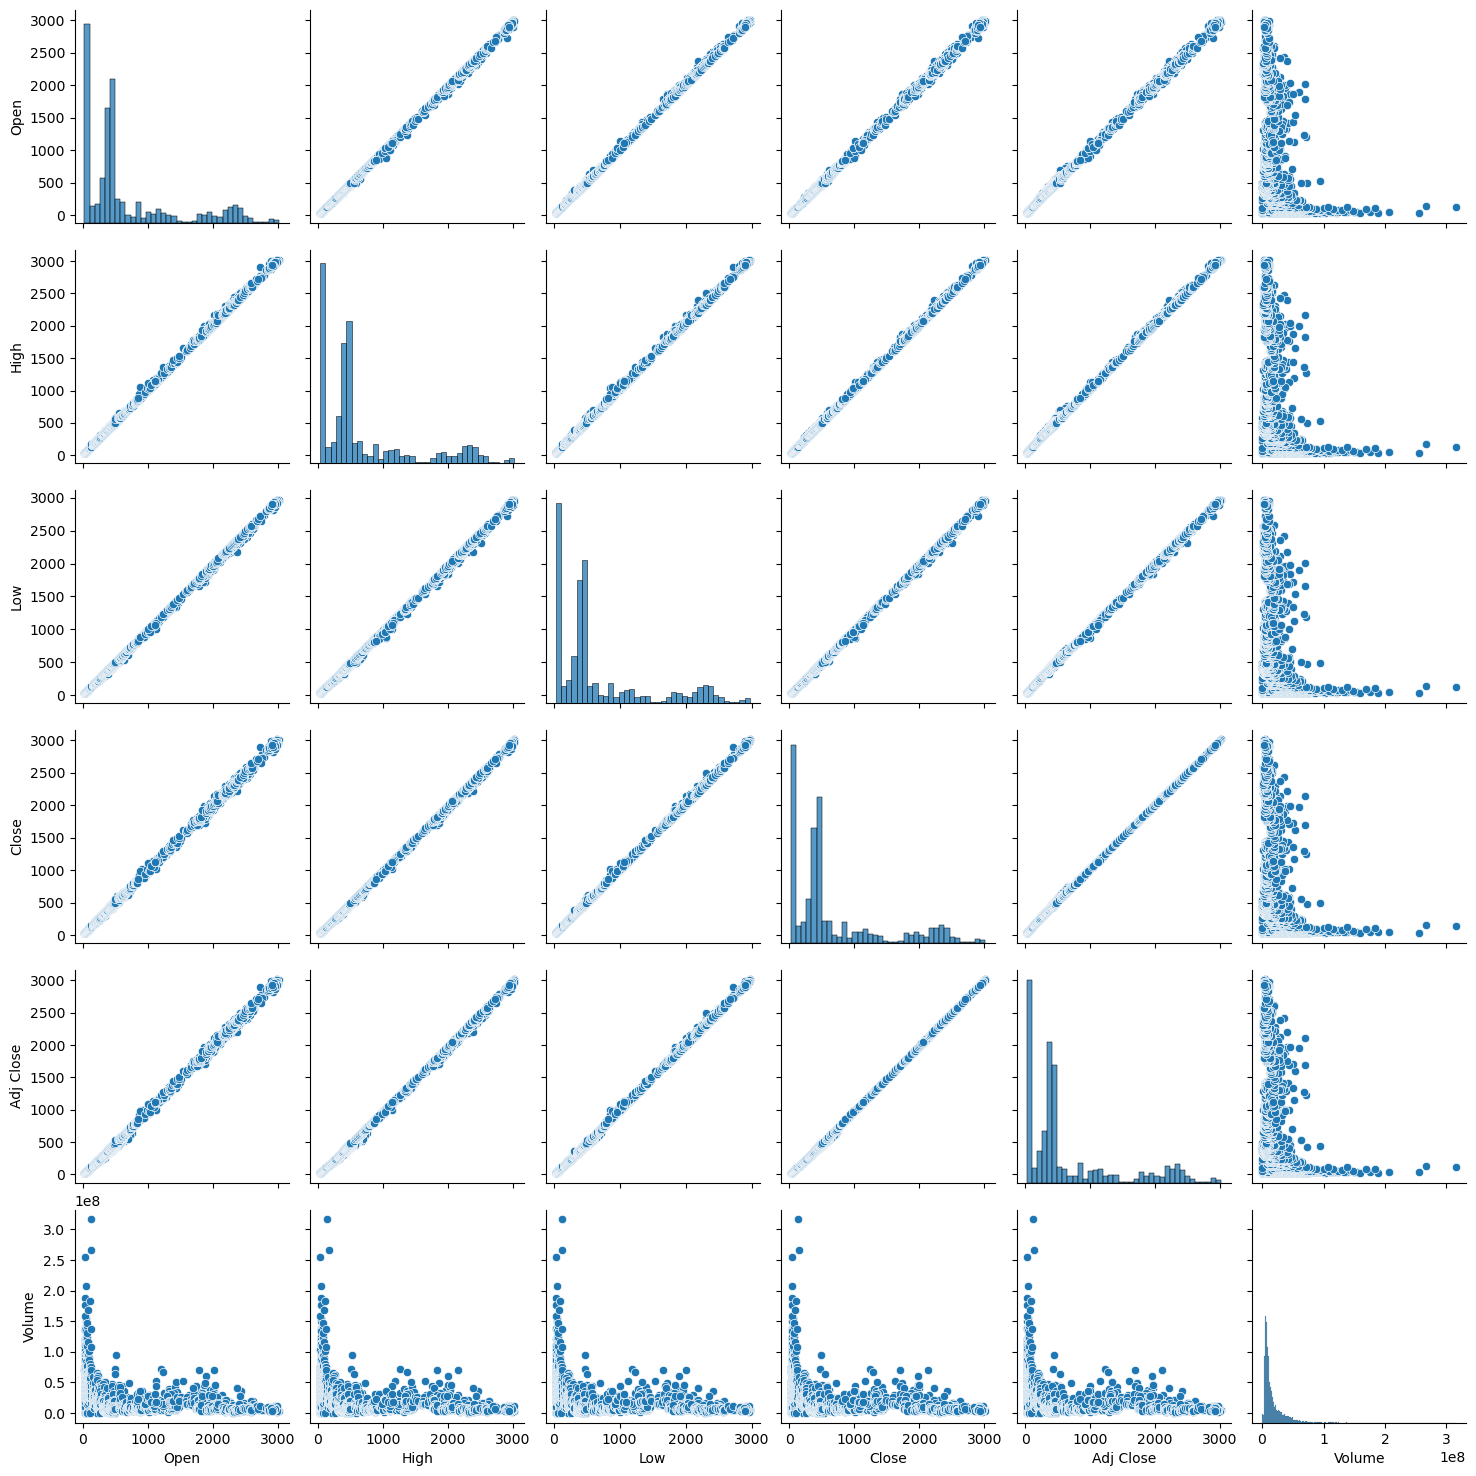

In [50]:
#pair plot
pair_cols = [
    'Date',
    'Open',
    'High', 
    'Low',
    'Close',
    'Adj Close',
    'Volume'
]

# Create pair plot
sns.pairplot(df[pair_cols], diag_kind='hist')
plt.show()

In [51]:
#Explanation: Generates pairwise relationship plots among selected features.
#Why: Helps detect multicollinearity and feature interactions.

In [52]:
df.corr(numeric_only=True)

,Open,High,Low,Close,Adj Close,Volume,MA50,MA200,Returns,Volatility_30,Log_Close,Diff_Log_Close
Open,1.000000,0.999894,0.999888,0.999781,0.999589,-0.339572,0.996055,0.990309,-0.006413,-0.114082,0.841181,0.005413
High,0.999894,1.000000,0.999856,0.999912,0.999689,-0.338107,0.995984,0.990230,-0.005603,-0.114097,0.841747,0.007366
Low,0.999888,0.999856,1.000000,0.999905,0.999753,-0.340683,0.995992,0.990387,-0.005635,-0.114062,0.840546,0.007338
Close,0.999781,0.999912,0.999905,1.000000,0.999811,-0.339234,0.995920,0.990300,-0.004887,-0.114097,0.841155,0.009100
Adj Close,0.999589,0.999689,0.999753,0.999811,1.000000,-0.333984,0.996188,0.990750,-0.005287,-0.111816,0.833873,0.008485
Volume,-0.339572,-0.338107,-0.340683,-0.339234,-0.333984,1.000000,-0.332595,-0.332371,0.001134,0.129806,-0.510490,0.002984
MA50,0.996055,0.995984,0.995992,0.995920,0.996188,-0.332595,1.000000,0.995035,-0.016761,-0.112564,0.832894,-0.002894
MA200,0.990309,0.990230,0.990387,0.990300,0.990750,-0.332371,0.995035,1.000000,-0.016916,-0.115032,0.829218,-0.001771
Returns,-0.006413,-0.005603,-0.005635,-0.004887,-0.005287,0.001134,-0.016761,-0.016916,1.000000,0.154526,0.006900,0.757541
Volatility_30,-0.114082,-0.114097,-0.114062,-0.114097,-0.111816,0.129806,-0.112564,-0.115032,0.154526,1.000000,-0.181606,-0.006906


In [53]:
#xplanation: Computes correlation values numerically.
#Why: Provides exact correlation coefficients for interpretation.

In [54]:
#=======================
#Feature Engineering
#=======================

In [55]:
#check current columns
print("Columns before feature engineering:")
print(df.columns)
print("Shape before feature engineering:", df.shape)

Columns before feature engineering:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'MA50',
       'MA200', 'Returns', 'Volatility_30', 'Log_Close', 'Diff_Log_Close'],
      dtype='object')
Shape before feature engineering: (6079, 13)


In [56]:
#Explanation: Displays existing features and dataset size.
#Why: To track feature growth before engineering.

In [57]:
#Create Lag Features
df['Lag1'] = df['Adj Close'].shift(1)
df['Lag7'] = df['Adj Close'].shift(7)
df['Lag30'] = df['Adj Close'].shift(30)

print("\nLag features created.")
df[['Adj Close','Lag1','Lag7','Lag30']].head(10)


Lag features created.


,Adj Close,Lag1,Lag7,Lag30
0,26.684866,NaN,NaN,NaN
1,28.821142,26.684866,NaN,NaN
2,29.950235,28.821142,NaN,NaN
3,31.206556,29.950235,NaN,NaN
4,33.348133,31.206556,NaN,NaN
5,32.706718,33.348133,NaN,NaN
6,30.586346,32.706718,NaN,NaN
7,31.985792,30.586346,26.684866,NaN
8,33.061886,31.985792,28.821142,NaN
9,33.533669,33.061886,29.950235,NaN


In [58]:
#Explanation: Creates past value features of closing price.
#Why: Lag features capture temporal dependencies for forecasting models.

In [59]:
#Create Rolling Mean Features
df['Rolling_Mean_7'] = df['Adj Close'].rolling(7).mean()
df['Rolling_Mean_30'] = df['Adj Close'].rolling(30).mean()

print("\nRolling mean features created.")
df[['Adj Close','Rolling_Mean_7','Rolling_Mean_30']].head(15)


Rolling mean features created.


,Adj Close,Rolling_Mean_7,Rolling_Mean_30
0,26.684866,NaN,NaN
1,28.821142,NaN,NaN
2,29.950235,NaN,NaN
3,31.206556,NaN,NaN
4,33.348133,NaN,NaN
5,32.706718,NaN,NaN
6,30.586346,30.471999,NaN
7,31.985792,31.229275,NaN
8,33.061886,31.835095,NaN
9,33.533669,32.347014,NaN


In [60]:
#Explanation: Computes moving averages over time windows.
#Why: Moving averages capture short-term and long-term trends.

In [61]:
#Create Rolling Standard Deviation
df['Rolling_Std_7'] = df['Adj Close'].rolling(7).std()
df['Rolling_Std_30'] = df['Adj Close'].rolling(30).std()

print("\nRolling std features created.")
df[['Adj Close','Rolling_Std_7','Rolling_Std_30']].head(15)


Rolling std features created.


,Adj Close,Rolling_Std_7,Rolling_Std_30
0,26.684866,NaN,NaN
1,28.821142,NaN,NaN
2,29.950235,NaN,NaN
3,31.206556,NaN,NaN
4,33.348133,NaN,NaN
5,32.706718,NaN,NaN
6,30.586346,2.278841,NaN
7,31.985792,1.586066,NaN
8,33.061886,1.296397,NaN
9,33.533669,1.124122,NaN


In [62]:
#Explanation: Calculates rolling volatility.
#Why: Measures price variability over time.

In [63]:
#Returns-Based Features
df['Returns'] = df['Adj Close'].pct_change()
df['Rolling_Return_Mean_7'] = df['Returns'].rolling(7).mean()

print("\nReturns features created.")
df[['Returns','Rolling_Return_Mean_7']].head(15)


Returns features created.


,Returns,Rolling_Return_Mean_7
0,NaN,NaN
1,0.080056,NaN
2,0.039176,NaN
3,0.041947,NaN
4,0.068626,NaN
5,-0.019234,NaN
6,-0.064830,NaN
7,0.045754,0.027356
8,0.033643,0.020726
9,0.014270,0.017168


In [64]:
#Explanation: Calculates daily percentage change in price.
#Why: Returns are more stable and commonly used in financial modeling.

In [65]:
#Drop NaN Rows
print("\nShape before dropping NaN:", df.shape)
df = df.dropna()
print("Shape after dropping NaN:", df.shape)


Shape before dropping NaN: (6079, 21)
Shape after dropping NaN: (5880, 21)


In [66]:
#Explanation: Removes rows created due to shifting and rolling operations.
#Why: Machine learning models cannot handle missing values.

In [67]:
print("\nFinal Columns:")
print(df.columns)


Final Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'MA50',
       'MA200', 'Returns', 'Volatility_30', 'Log_Close', 'Diff_Log_Close',
       'Lag1', 'Lag7', 'Lag30', 'Rolling_Mean_7', 'Rolling_Mean_30',
       'Rolling_Std_7', 'Rolling_Std_30', 'Rolling_Return_Mean_7'],
      dtype='object')


In [68]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,MA50,MA200,Returns,...,Log_Close,Diff_Log_Close,Lag1,Lag7,Lag30,Rolling_Mean_7,Rolling_Mean_30,Rolling_Std_7,Rolling_Std_30,Rolling_Return_Mean_7
199,2000-10-06,48.277657,48.813202,48.063438,48.613266,36.936382,14598733.0,37.340030,35.125807,0.000735,...,3.609197,0.000735,36.909256,38.184227,36.198513,37.217725,38.035933,0.263886,1.644034,-0.004684
200,2000-10-09,48.698952,49.484421,48.420471,48.620407,36.941807,17267329.0,37.347951,35.177092,0.000147,...,3.609344,0.000147,36.936382,37.500618,36.046608,37.137894,38.065773,0.248095,1.614541,-0.002106
201,2000-10-10,48.706093,48.770359,47.613583,47.870644,36.372128,15003643.0,37.340789,35.214847,-0.015421,...,3.593803,-0.015541,36.941807,37.164246,35.851288,37.024735,38.083134,0.379775,1.592558,-0.003028
202,2000-10-11,47.556458,47.756393,46.785271,47.170864,35.840431,13593385.0,37.321909,35.244298,-0.014618,...,3.579077,-0.014726,36.372128,37.164246,36.556602,36.835618,38.059262,0.577080,1.621338,-0.005116
203,2000-10-12,46.770988,47.770676,46.064068,46.749565,35.520340,34541080.0,37.299556,35.265867,-0.008931,...,3.570105,-0.008971,35.840431,37.234776,36.518627,36.590699,38.025986,0.724438,1.663738,-0.006663


In [69]:
#=============================================
#Model Building
#=============================================

In [70]:
# Ensure Date is datetime and set as index
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    df = df.set_index('Date')

In [71]:
#Explanation: We converted the Date column into datetime format, sorted the data chronologically, and set it as the index.
#Why:Time-series forecasting requires strictly ordered data. Setting Date as the index ensures accurate time-based slicing and prevents misalignment.

In [72]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA50,MA200,Returns,Volatility_30,Log_Close,Diff_Log_Close,Lag1,Lag7,Lag30,Rolling_Mean_7,Rolling_Mean_30,Rolling_Std_7,Rolling_Std_30,Rolling_Return_Mean_7
Date,,,,,,,,,,,,,,,,,,,,
2000-10-06,48.277657,48.813202,48.063438,48.613266,36.936382,14598733.0,37.340030,35.125807,0.000735,0.021586,3.609197,0.000735,36.909256,38.184227,36.198513,37.217725,38.035933,0.263886,1.644034,-0.004684
2000-10-09,48.698952,49.484421,48.420471,48.620407,36.941807,17267329.0,37.347951,35.177092,0.000147,0.021566,3.609344,0.000147,36.936382,37.500618,36.046608,37.137894,38.065773,0.248095,1.614541,-0.002106
2000-10-10,48.706093,48.770359,47.613583,47.870644,36.372128,15003643.0,37.340789,35.214847,-0.015421,0.021745,3.593803,-0.015541,36.941807,37.164246,35.851288,37.024735,38.083134,0.379775,1.592558,-0.003028
2000-10-11,47.556458,47.756393,46.785271,47.170864,35.840431,13593385.0,37.321909,35.244298,-0.014618,0.021615,3.579077,-0.014726,36.372128,37.164246,36.556602,36.835618,38.059262,0.577080,1.621338,-0.005116
2000-10-12,46.770988,47.770676,46.064068,46.749565,35.520340,34541080.0,37.299556,35.265867,-0.008931,0.021671,3.570105,-0.008971,35.840431,37.234776,36.518627,36.590699,38.025986,0.724438,1.663738,-0.006663


In [73]:
#Chronological Train-Test Split using .loc function
train = df.loc[:'2022-12-31']
test  = df.loc['2023-01-01':]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (5556, 20)
Test shape: (324, 20)


In [74]:
#Explanation:We split the dataset chronologically, using historical data for training and the most recent year for testing.
#Why:Stock data is sequential and time-dependent. Using .loc preserves temporal order and prevents data leakage that occurs with random splitting.

In [75]:
#Target variable
target = 'Adj Close'

features = train.columns.drop(target)
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]
print("Number of features:", len(features))

Number of features: 19


In [76]:
#Training Baseline
from xgboost import XGBRegressor

baseline_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

In [77]:
#Evaluate Baseline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_base = mean_absolute_error(y_test, y_pred_baseline)
mse_base = mean_squared_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test, y_pred_baseline)

print("Baseline MAE:", round(mae_base,2))
print("Baseline RMSE:", round(rmse_base,2))
print("Baseline R2:", round(r2_base,4))

Baseline MAE: 91.03
Baseline RMSE: 178.99
Baseline R2: 0.5555


In [78]:
#Explanation: We selected Adj Close as the target variable and used the remaining engineered features as predictors.
#Why: Adjusted Close accounts for corporate actions like dividends and stock splits, making it more reliable for forecasting.

In [79]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [80]:
from xgboost import XGBRegressor
print("XGBoost loaded successfully")

XGBoost loaded successfully


In [81]:
from xgboost import XGBRegressor

# Baseline XGBoost model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)
# Train model
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [82]:
#Explanation:We trained a baseline XGBoost regression model using the engineered time-series features.
#Why:XGBoost is powerful for capturing nonlinear relationships, volatility patterns, and complex interactions in financial datasets

In [83]:
#Intial prediction on test set
y_pred = model.predict(X_test)

print("First 5 Predictions:")
print(y_pred[:5])

First 5 Predictions:
[2361.1545 2364.0574 2323.0679 2317.8406 2338.8108]


In [84]:
#Explanation: The trained model was used to predict stock prices on the test dataset.
#Why: This allows us to evaluate how well the model performs on unseen future data.

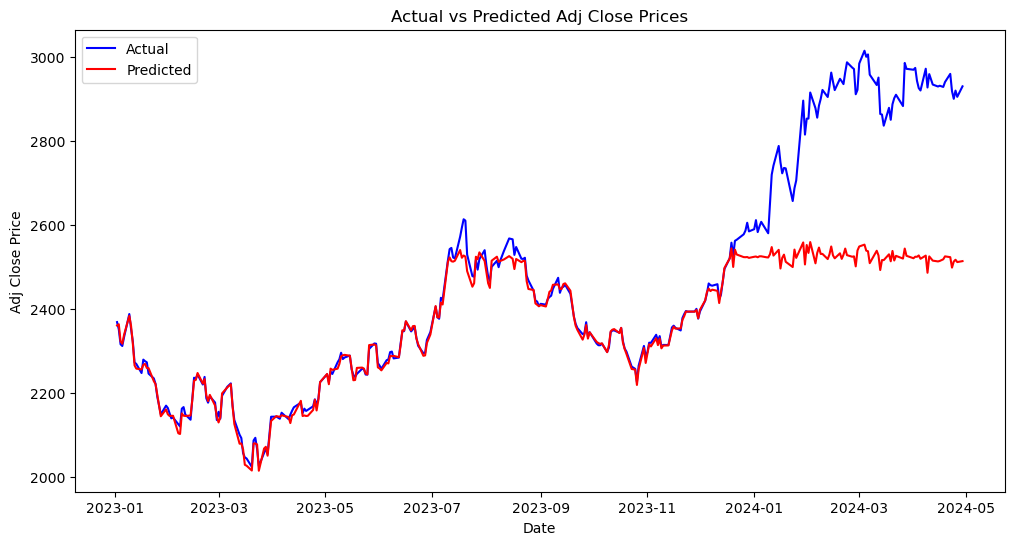

In [85]:
#Visual comparision 
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted', color='red')
plt.legend()
plt.title("Actual vs Predicted Adj Close Prices")
plt.xlabel("Date")
plt.ylabel("Adj Close Price")
plt.show()

In [86]:
#Explanation: We plotted actual and predicted prices for comparison.
#Why: Visual comparison helps assess trend alignment and overall model behavior before applying formal evaluation metrics.

In [87]:
#Prepare data for Walk-forward
df = df.sort_index()

target = 'Adj Close'
features = df.columns.drop(target)

X = df[features]
y = df[target]

In [88]:
#Explanation: We sorted the dataset chronologically and separated features (X) and the target variable (Adj Close).
#Why: Time-series forecasting requires strictly ordered data. Separating features and target ensures the model learns relationships correctly without data leakage.

In [89]:
print("Feature columns:",list(features))

Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'MA50', 'MA200', 'Returns', 'Volatility_30', 'Log_Close', 'Diff_Log_Close', 'Lag1', 'Lag7', 'Lag30', 'Rolling_Mean_7', 'Rolling_Mean_30', 'Rolling_Std_7', 'Rolling_Std_30', 'Rolling_Return_Mean_7']


In [90]:
#Chronological split
split_index = int(len(df) * 0.8)

train_X = X.iloc[:split_index]
test_X  = X.iloc[split_index:]
train_y = y.iloc[:split_index]
test_y  = y.iloc[split_index:]

print("Train size:", train_X.shape)
print("Test size:", test_X.shape)

Train size: (4704, 19)
Test size: (1176, 19)


In [91]:
#Explanation :We split the dataset chronologically, using 80% for training and 20% for testing.
#Why: Random splitting is not suitable for stock forecasting. Chronological splitting preserves time order and prevents future information from influencing the model.

In [92]:
predictions = []

history_X = train_X.copy()
history_y = train_y.copy()

#Retrain every 10-steps
retrain_interval = 10   

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror')

for i in range(len(test_X)):
    
    # Retrain only every 'retrain_interval' steps
    if i % retrain_interval == 0:
        model.fit(history_X, history_y)
    
    y_hat = model.predict(test_X.iloc[i:i+1])
    predictions.append(y_hat[0])
    
    # Expand history
    history_X = pd.concat([history_X, test_X.iloc[i:i+1]])
    history_y = pd.concat([history_y, test_y.iloc[i:i+1]])

In [93]:
#Explanation: We implemented walk-forward validation where the model is periodically retrained using expanding historical data and then used to predict the next time step.
#Why: Stock markets evolve over time. Walk-forward validation simulates real-world forecasting conditions and ensures predictions are made using only past information.

In [94]:
#Convert predictions to series 
pred_series = pd.Series(predictions, index=test_y.index)
pred_series.head()

Date
2019-07-25    1099.701294
2019-07-26    1085.733643
2019-07-29    1080.411865
2019-07-30    1070.928833
2019-07-31    1038.320557
dtype: float32

In [95]:
#Explanation: We converted predictions into a pandas Series aligned with the test dataset dates.
#Why: Aligning predictions with actual dates ensures accurate comparison and visualization.

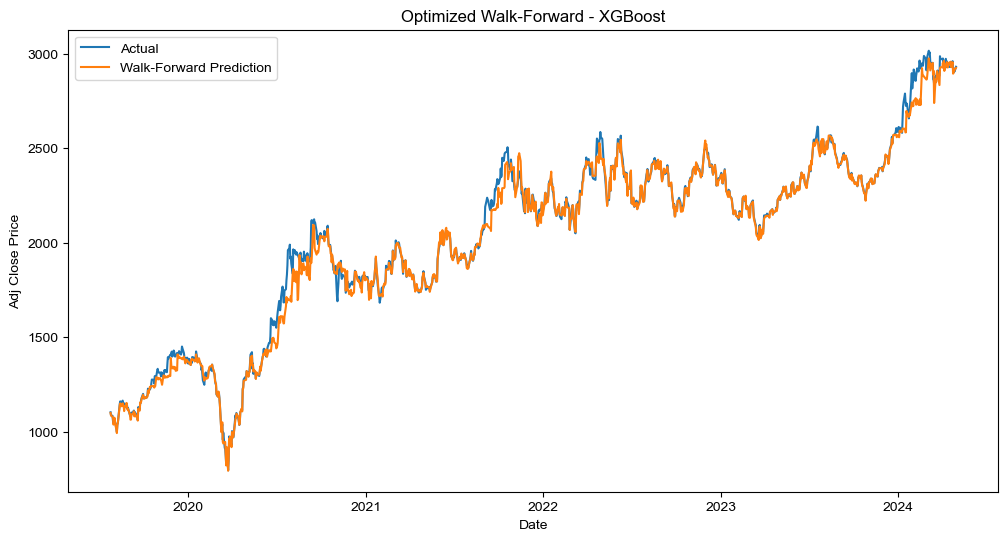

In [96]:
plt.figure(figsize=(12,6))
plt.plot(test_y.index, test_y, label='Actual')
plt.plot(pred_series.index, pred_series, label='Walk-Forward Prediction')
plt.legend()
plt.title("Optimized Walk-Forward - XGBoost")
plt.xlabel("Date")
plt.ylabel("Adj Close Price")
plt.style.use('seaborn-v0_8')
plt.show()

In [97]:
#Explanation: We plotted actual and predicted Adjusted Close prices for the test period.
#Why: Visual validation helps evaluate trend alignment and model stability before formal performance evaluation.

In [98]:
len(predictions)

1176

In [99]:
#Explantaion: To Check our test_x size is similar after conversion as well

In [100]:
# Final Model Building Summary:-
# In this phase, we built a forecasting model using XGBoost Regressor 
# with engineered time-series features.
# The dataset was first sorted chronologically and split using 
# a time-based (non-random) train-test split to avoid data leakage.
# We implemented Walk-Forward Validation to simulate real-world 
# stock market forecasting, where predictions are made sequentially 
# using only past information.
# The model was periodically retrained using expanding historical data 
# to adapt to changing market patterns.
# Finally, predictions were aligned with actual values and visualized 
# to assess trend accuracy and model stability.
# The model is now ready for hyperparameter tuning and formal evaluation.

In [101]:
#======================
#Hyperparameter tuning
#======================

In [102]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

# TimeSeries Split (Preserves chronological order)
tscv = TimeSeriesSplit(n_splits=3)

# Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]}

# Base XGBosst Model
xgb_model = XGBRegressor(objective='reg:squarederror',random_state=42)

In [103]:
#Explanation: We imported GridSearchCV for hyperparameter optimization and TimeSeriesSplit to perform time-aware cross-validation.
#Why: Stock data is sequential. TimeSeriesSplit ensures past data is used to predict future data, preventing data leakage during tuning.
#TimeSeries Split:- We defined a time-based cross-validation strategy with 3 splits,
# unlike normal K-Fold, TimeSeriesSplit preserves chronological order, making it suitable for stock forecasting problems.
# Paremeter Grid explantion:- We defined different combinations of key XGBoost hyperparameters to search for the optimal configuration.
# Why: Hyperparameters control model complexity and learning behavior. Tuning them improves prediction accuracy and prevents underfitting or overfitting.
# We initialized the base XGBoost regression model by using objective as 'reg:squarederror' is appropriate for continuous price prediction.

In [104]:
# Grid Search
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,                # Time-series safe CV
    scoring='neg_mean_squared_error',  
    n_jobs=-1,
    verbose=1)

In [105]:
#Explanation: We configured GridSearchCV to test all parameter combinations using time-series cross-validation.
#Why: Using 'neg_mean_squared_error' ensures the model is optimized based on prediction error rather than variance explanation Like this is appropriate for stock market forecasting

In [106]:
# Fit on training data only
grid_search.fit(train_X, train_y)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [107]:
# Best Model
best_xgb = grid_search.best_estimator_
print("Best Parameters Found:", grid_search.best_params_)

Best Parameters Found: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


In [108]:
#Explanation: We extracted the best-performing model and displayed its optimal hyperparameters.
#Why: The best estimator represents the model configuration that achieved the lowest prediction error during cross-validation.

In [109]:
# Predict on test set using tuned model
y_pred_tuned = best_xgb.predict(test_X)

# Show first 5 predictions
print("First 5 Predictions:", y_pred_tuned[:5])

First 5 Predictions: [1100.415  1084.5403 1081.047  1071.4884 1039.9746]


In [110]:
#Explanation: We generated predictions on the unseen test dataset using the tuned XGBoost model.
#Why: This allows us to assess the model’s forecasting performance after hyperparameter optimization.

In [111]:
# ===============================
# Model Comparison
# ===============================

# Recompute predictions properly
y_pred_baseline = baseline_model.predict(X_test)
y_pred_tuned = best_xgb.predict(X_test)

In [112]:
# Baseline Metrics
mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base = r2_score(y_test, y_pred_baseline)

# Tuned Metrics
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

In [113]:
#Comparison table
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Baseline Model": [mae_base, rmse_base, r2_base],
    "Tuned Model": [mae_tuned, rmse_tuned, r2_tuned]
})

print(comparison)

  Metric  Baseline Model  Tuned Model
0    MAE       91.033100  1228.694911
1   RMSE      178.994112  1257.331821
2     R2        0.555539   -20.930899


In [114]:
#Explanation: This block compares baseline and tuned models using standard regression metrics on the same test data. 
#It ensures objective model selection based on performance rather than assumption.

In [115]:
#============================
#Model Evaluation
#===========================

In [116]:
# Generate predictions using FINAL selected model
y_pred = baseline_model.predict(X_test)

In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R2 Score:", round(r2, 4))

Mean Absolute Error (MAE): 91.03
Mean Squared Error (MSE): 32038.89
Root Mean Squared Error (RMSE): 178.99
R2 Score: 0.5555


In [118]:
#Explanation: This section evaluates the selected baseline model on unseen test data using MAE, MSE, RMSE, and R².
#Why: It quantifies real-world forecasting accuracy and confirms model reliability.
#Explantion for why baseline was selected
#The baseline model achieved lower MAE and RMSE with a positive R² (0.5555), indicating better predictive accuracy and stronger generalization on unseen data.
#The tuned model produced higher errors and a negative R², showing poor performance. Therefore, the baseline model was selected as the final model.

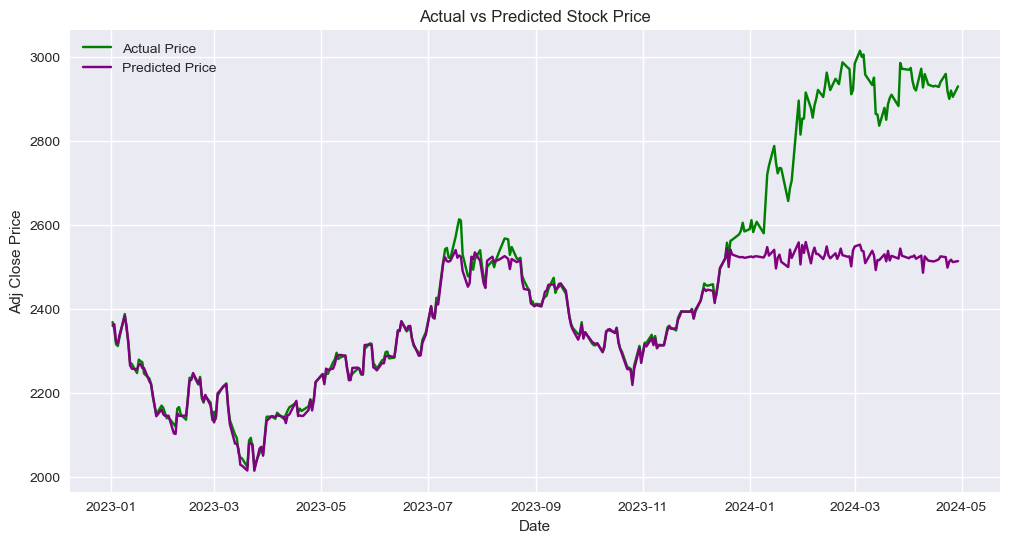

In [119]:
# Actual vs Predicted Plot

plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual Price", color="green")
plt.plot(y_test.index, y_pred, label="Predicted Price", color="purple")
plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Date")
plt.ylabel("Adj Close Price")
plt.legend()
plt.show()

In [120]:
#Explanation: This visualization compares actual and predicted prices over time.
#Why: It validates whether the model captures trend direction and market movements effectively beyond numerical metrics.

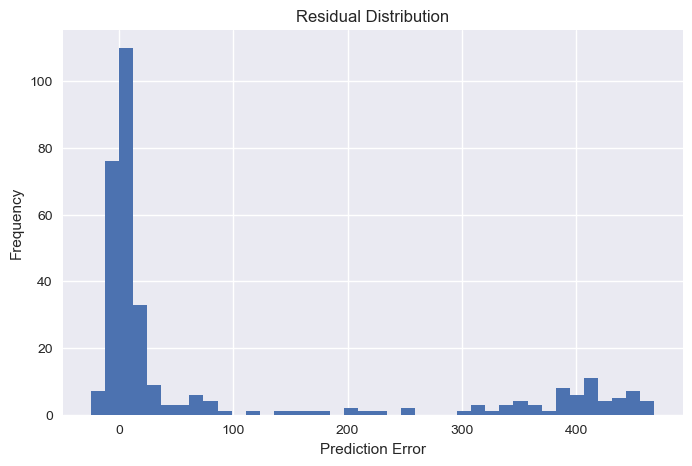

In [121]:
# Residuals analysis
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=40)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

In [122]:
#Explanation: Residuals represent the difference between actual and predicted values.
#Why: Analyzing residual distribution helps detect bias, variance, and systematic prediction errors.

In [123]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                  Feature  Importance
9               Log_Close    0.641161
3                   Close    0.184329
1                    High    0.053688
2                     Low    0.047216
11                   Lag1    0.037869
5                    MA50    0.023090
14         Rolling_Mean_7    0.007419
0                    Open    0.004669
15        Rolling_Mean_30    0.000243
6                   MA200    0.000172
13                  Lag30    0.000072
12                   Lag7    0.000034
7                 Returns    0.000008
8           Volatility_30    0.000007
18  Rolling_Return_Mean_7    0.000007
17         Rolling_Std_30    0.000006
16          Rolling_Std_7    0.000005
4                  Volume    0.000004
10         Diff_Log_Close    0.000000


In [124]:
#Explanation: This extracts feature importance scores from the tuned XGBoost model.
#Why: It identifies which engineered features contribute most to price prediction.

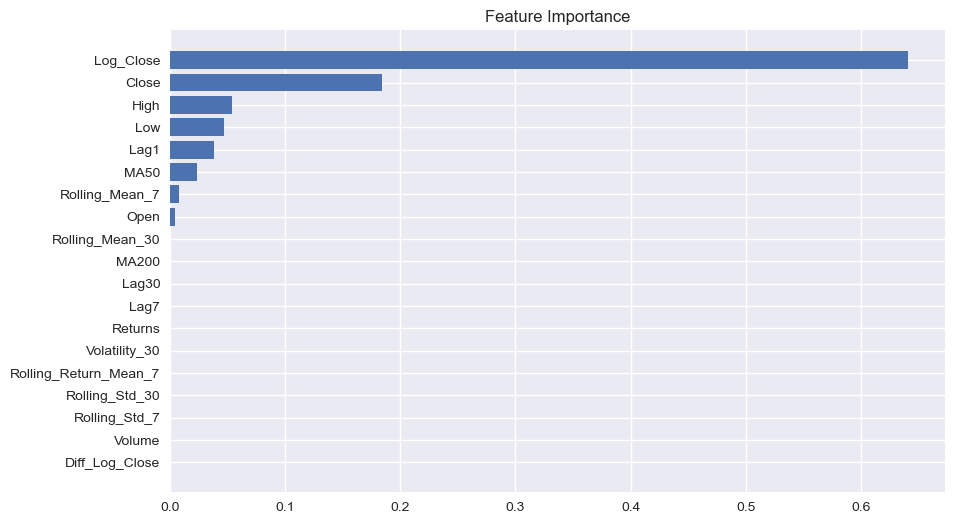

In [125]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [126]:
# =========================================
# Final Selected Model
# =========================================

print("Final Selected Model: Tuned XGBoost Regressor")
print(best_xgb)

Final Selected Model: Tuned XGBoost Regressor
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


In [127]:
# Refit tuned model on full training data
best_xgb.fit(train_X, train_y)
print("Model refitted successfully on full training data.")

Model refitted successfully on full training data.


In [128]:

import joblib

joblib.dump(best_xgb, "final_xgboost_model.pkl")
print("Final model saved as final_xgboost_model.pkl")

Final model saved as final_xgboost_model.pkl
